In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    auc
)

In [2]:
df = pd.read_csv("D:\DataScience\Data\CustomerChurn\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df = df.drop(columns=["customerID"])

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\CM\AppData\Local\Temp\ipykernel_7740\4001076008.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("D:\DataScience\Data\CustomerChurn\WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [3]:
categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [4]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [5]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [6]:
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"ROC-AUC: {roc_auc_rf:.3f}")

[[878 157]
 [149 225]]
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.59      0.60      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

ROC-AUC: 0.835


In [7]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

In [8]:
gb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [9]:
y_pred_gb = gb_pipeline.predict(X_test)
y_proba_gb = gb_pipeline.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

roc_auc_gb = roc_auc_score(y_test, y_proba_gb)
print(f"ROC-AUC: {roc_auc_gb:.3f}")

[[938  97]
 [185 189]]
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.844


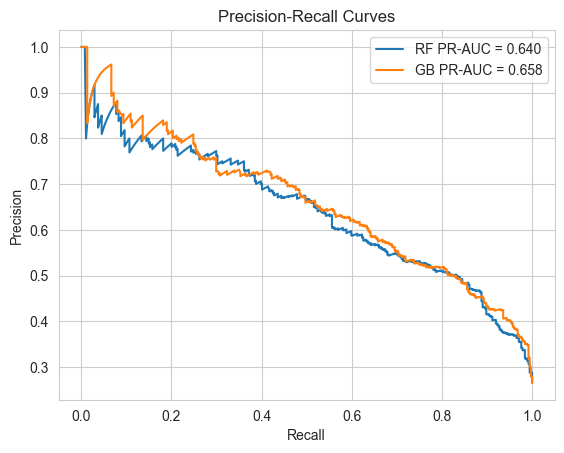

In [10]:
from matplotlib import pyplot as plt

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)
precision_gb, recall_gb, _ = precision_recall_curve(y_test, y_proba_gb)

pr_auc_rf = auc(recall_rf, precision_rf)
pr_auc_gb = auc(recall_gb, precision_gb)

plt.plot(recall_rf, precision_rf, label=f"RF PR-AUC = {pr_auc_rf:.3f}")
plt.plot(recall_gb, precision_gb, label=f"GB PR-AUC = {pr_auc_gb:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.title("Precision-Recall Curves")
plt.show()

In [11]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "ROC-AUC": [roc_auc_rf, roc_auc_gb],
    "PR-AUC": [pr_auc_rf, pr_auc_gb]
})

results

,Model,ROC-AUC,PR-AUC
0,Random Forest,0.835059,0.640335
1,Gradient Boosting,0.843911,0.657945


In [12]:
# Get feature names after preprocessing
ohe = gb_pipeline.named_steps["preprocessor"] \
                 .named_transformers_["cat"] \
                 .named_steps["onehot"]

categorical_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, categorical_feature_names])

In [13]:
importances = gb_pipeline.named_steps["classifier"].feature_importances_

feature_importance_df = (
    pd.DataFrame({
        "feature": all_feature_names,
        "importance": importances
    })
    .sort_values(by="importance", ascending=False)
)

feature_importance_df.head(15)

,feature,importance
1,tenure,0.292058
10,InternetService_Fiber optic,0.190407
28,PaymentMethod_Electronic check,0.126958
25,Contract_Two year,0.078942
3,TotalCharges,0.070195
24,Contract_One year,0.062001
2,MonthlyCharges,0.045975
26,PaperlessBilling_Yes,0.022609
13,OnlineSecurity_Yes,0.016917
19,TechSupport_Yes,0.013038


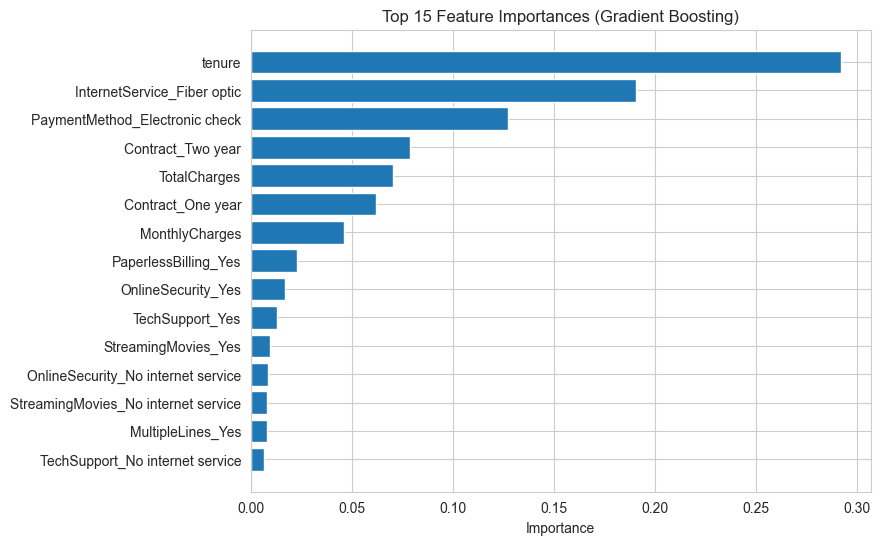

In [14]:
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Gradient Boosting)")
plt.xlabel("Importance")
plt.show()

In [15]:
X_test_scored = X_test.copy()
X_test_scored["churn_probability"] = y_proba_gb
X_test_scored["actual_churn"] = y_test.values

X_test_scored.sort_values("churn_probability", ascending=False).head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,churn_probability,actual_churn
3380,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.10,95.10,0.919692,1
6623,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,76.45,76.45,0.918540,1
6866,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,95.45,0.907316,1
2464,Female,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,77.15,77.15,0.901011,1
4585,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,No,Yes,Month-to-month,Yes,Electronic check,85.05,85.05,0.899500,1


In [16]:
import shap
import numpy as np

C:\Users\CM\PyCharmMiscProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'train_test_split', 'GridSearchCV', 'StandardScaler', 'OneHotEncoder', 'ColumnTransformer', 'Pipeline', 'RandomForestClassifier', 'GradientBoostingClassifier', 'confusion_matrix', 'classification_report', 'roc_auc_score', 'precision_recall_curve', 'auc', '_i2', 'df', 'X', 'y', 'X_train', 'X_test', 'y_train', 'y_test', '_i3', 'categorical_features', 'numeric_features', 'numeric_transformer', 'categorical_transformer', 'preprocessor', '_i4', 'rf_pipeline', '_i5', '_5', '_i6', 'y_pred_rf', 'y_proba_rf', 'roc_auc_rf', '_i7', 'gb_pipeline', '_i8', '_8', '_i9', 'y_pred_gb', 'y_proba_gb', 'roc_auc_gb', '_i10', 'plt', 'precision_rf', 'recall_rf', 'precision_gb', 'recall_gb', 'pr_auc_rf', 'pr_auc_gb', '_i11', 'results', '_11', '_i12', 'ohe', 'cate

In [18]:
gb_model = gb_pipeline.named_steps["classifier"]

In [19]:
X_train_transformed = gb_pipeline.named_steps["preprocessor"].transform(X_train)

In [20]:
explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_train_transformed)

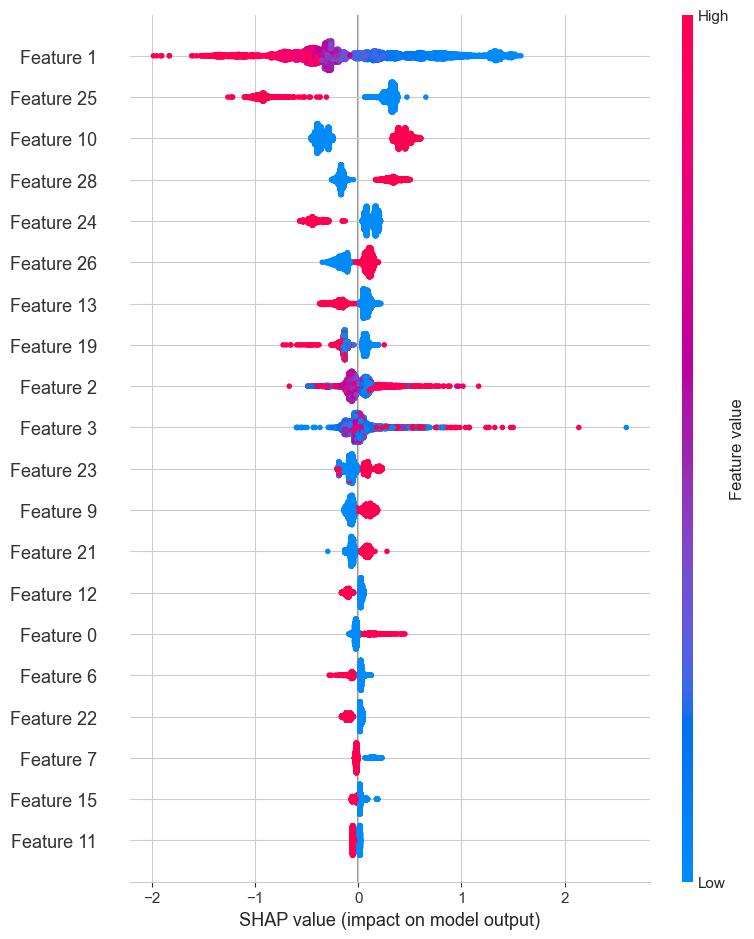

In [21]:
shap.summary_plot(shap_values, X_train_transformed)

In [22]:
import numpy as np

idx = np.where(y_train == 1)[0][0]  # first churned customer


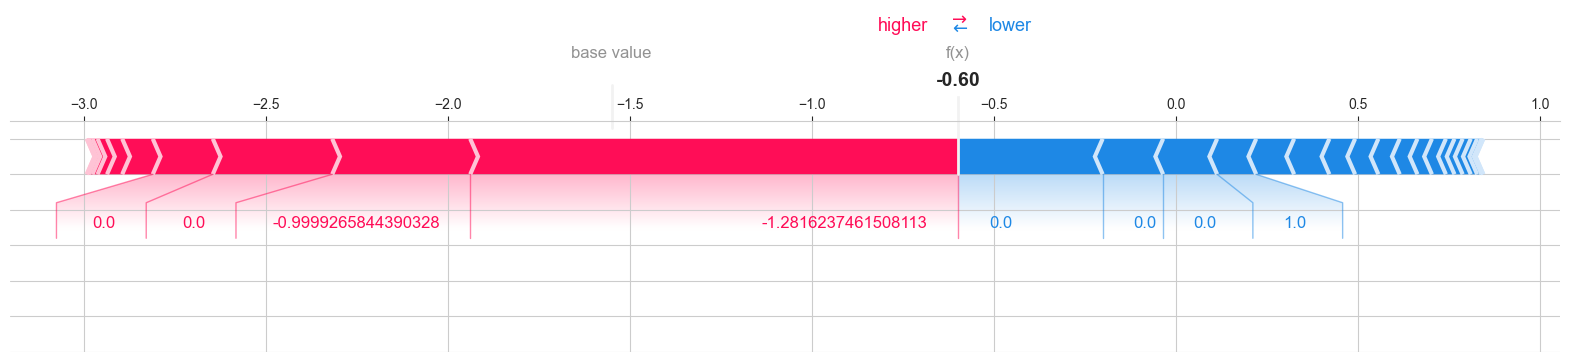

In [23]:
shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_train_transformed[idx],
    matplotlib=True
)

Bridge

In [24]:
y_train_proba = gb_pipeline.predict_proba(X_train)[:, 1]
y_test_proba  = gb_pipeline.predict_proba(X_test)[:, 1]


In [25]:
import pandas as pd

risk_segments = pd.Series(
    pd.cut(
        y_test_proba,
        bins=[0, 0.3, 0.6, 1.0],
        labels=["Low Risk", "Medium Risk", "High Risk"]
    ),
    name="risk_segment"
)


In [26]:
risk_segments.value_counts(normalize=True)


risk_segment
Low Risk       0.615330
Medium Risk    0.251242
High Risk      0.133428
Name: proportion, dtype: float64

In [27]:
segment_df = pd.concat(
    [
        risk_segments.reset_index(drop=True),
        y_test.reset_index(drop=True)
    ],
    axis=1
)

segment_df.head()


,risk_segment,Churn
0,Low Risk,0
1,High Risk,0
2,Low Risk,0
3,Medium Risk,0
4,Low Risk,0


In [28]:
segment_df.groupby("risk_segment")["Churn"].mean()


C:\Users\CM\AppData\Local\Temp\ipykernel_7740\1543270460.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_df.groupby("risk_segment")["Churn"].mean()


risk_segment
Low Risk       0.103806
Medium Risk    0.418079
High Risk      0.723404
Name: Churn, dtype: float64

In [29]:
X_test_transformed = gb_pipeline.named_steps["preprocessor"].transform(X_test)


In [30]:
gb_model = gb_pipeline.named_steps["classifier"]


In [31]:
import shap

explainer = shap.TreeExplainer(gb_model)


In [32]:
shap_values = explainer.shap_values(X_test_transformed)


In [33]:
high_risk_idx = risk_segments[risk_segments == "High Risk"].index

X_high_risk = X_test_transformed[high_risk_idx]
shap_high_risk = shap_values[high_risk_idx]


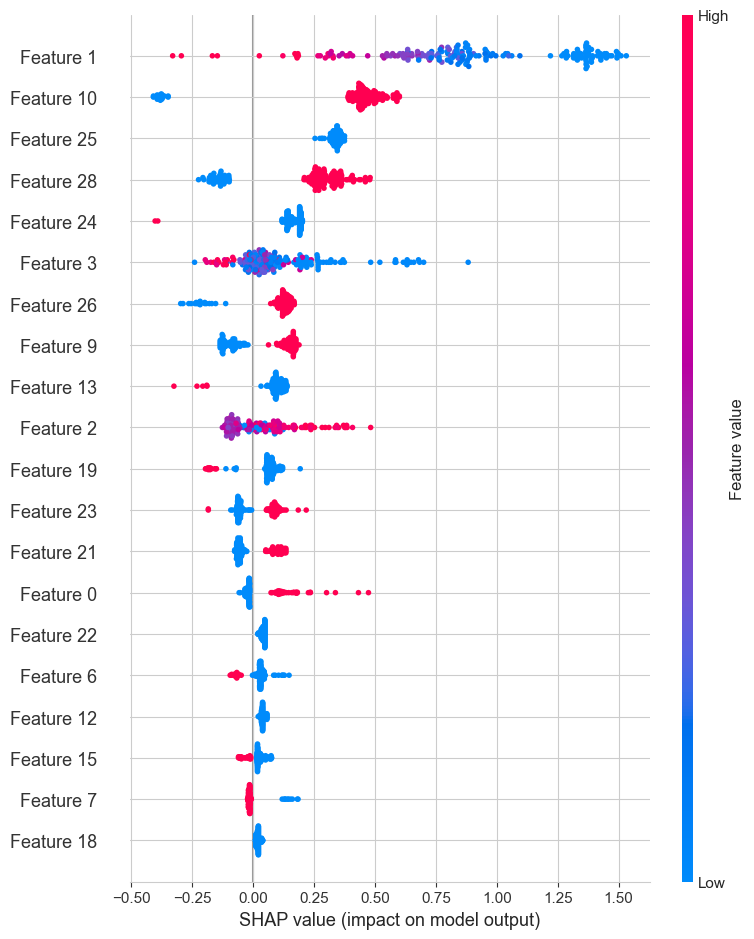

In [34]:
shap.summary_plot(shap_high_risk, X_high_risk)
